In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
sys.path.append("/root/limlab01/kaistai/25DFT/QHFlow/src")
import md.scflow_calculator_gpu
from dft_process.dft_process_utils import *
from common.draw_util import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [131]:
# md17_experiment = MD17Experiment(data_index=1)
# md17_experiment.set_model_path()
qh9_experiment = QH9Experiment(data_index=1, use_shard=True)

cur_ckpt = "/root/25DFT/QHFlow/src/outputs/QH9Stable-random/QHFlow_so2_v5_1_large-QH9Stable-random/checkpoints/weights-epoch=78-val_loss=0.0000000.ckpt"

In [132]:
qh9_experiment.dataset[0].dft_energy

tensor([[-40.4877]], dtype=torch.float64)

In [133]:
gt_outputs = qh9_experiment.dataset.get_gt_outputs(0)

In [134]:
gt_outputs

{'pos': tensor([[-1.2698e-02,  1.0858e+00,  8.0010e-03],
         [ 2.1504e-03, -6.0313e-03,  1.9761e-03],
         [ 1.0117e+00,  1.4638e+00,  2.7657e-04],
         [-5.4082e-01,  1.4475e+00, -8.7664e-01],
         [-5.2381e-01,  1.4379e+00,  9.0640e-01]], dtype=torch.float64),
 'atoms': tensor([[6],
         [1],
         [1],
         [1],
         [1]]),
 'hamiltonian': tensor([[-10.1627,  -3.5317,  -1.6758,  ...,  -0.4342,   0.2991,   0.7632],
         [ -3.5317,  -1.6945,  -1.1353,  ...,  -0.2141,   0.1475,   0.3763],
         [ -1.6758,  -1.1353,  -0.8022,  ...,  -0.1481,   0.1020,   0.2603],
         ...,
         [ -0.4342,  -0.2141,  -0.1481,  ...,   1.2700,   0.0483,   0.1233],
         [  0.2991,   0.1475,   0.1020,  ...,   0.0483,   1.3069,  -0.0850],
         [  0.7632,   0.3763,   0.2603,  ...,   0.1233,  -0.0850,   1.1234]],
        dtype=torch.float64),
 'overlap_matrix': tensor([[ 1.0000,  0.3256,  0.1518,  ...,  0.0387, -0.0267, -0.0680],
         [ 0.3256,  1.0000, 

In [135]:
# import Batch
from torch_geometric.data import Batch
qh9_d0 = Batch.from_data_list([qh9_experiment.dataset[0]])

In [136]:
sccalculator = md.scflow_calculator_gpu.SCFlowRKSCalculator(basis="def2-SVP", functional="b3lyp")
sccalculator.set_model(cur_ckpt, data_type="qh9", units="ang", model_length_unit="ang", mf_init_functional="b3lyp",)

INFO     [__init__.py:104] >> model_args: {'in_node_features': 1, 'sh_lmax': 4, 'hidden_size': 256,                
         'bottle_hidden_size': 64, 'num_gnn_layers': 4, 'max_radius': 15, 'num_nodes': 10, 'radius_embed_dim': 16, 
         'max_T': 15, 'use_block_S': True, 'use_block_H': True, 'ham_dim': 24, 'ham_hidden': 288, 'dataset_type':  
         'qh9', 'num_ham_gnn_layers': 2}

Setting device to cuda


INFO     [base_module.py:128] >> use_init_hamiltonian: True

INFO     [base_module.py:129] >> use_init_hamiltonian_residue: True

INFO     [base_module.py:130] >> ema_start_epoch: -1

INFO     [base_module.py:131] >> qh9: True

INFO     [base_module.py:132] >> test_mode: test

INFO     [flow_module.py:211] >> init_p0_type: expand

model trained on dataset:  QH9Stable
ode_steps: 1


In [137]:
mol = sccalculator.get_mol(qh9_d0.atoms, qh9_d0.pos)
ase_atoms = md.scflow_calculator_gpu.QHData_to_atoms(qh9_d0, unit="ang")
res2 = sccalculator.calculate(ase_atoms, properties=["energy", "forces"], system_changes=["positions"])

In [154]:
rkscalculator = md.scflow_calculator_gpu.RKSCalculator(basis="def2-SVP", functional="b3lyp", density_fit=False)
res3 = rkscalculator.calculate(ase_atoms, properties=["energy, forces"], system_changes=["positions"])
gt_fock = rkscalculator.mf.get_fock()

In [143]:
res3

{'energy': np.float64(-40.48765363940356), 'forces': 0, 'cycles': 6}

In [141]:
res2, res3

((np.float64(-40.487677861619844),
  array([[ 4.27218882e-06,  6.76667769e-06,  4.39395122e-07],
         [ 5.21098443e-05, -4.08939838e-03, -2.16039592e-05],
         [ 3.83347290e-03,  1.41454320e-03, -2.97108021e-05],
         [-1.97586737e-03,  1.35247553e-03, -3.31354687e-03],
         [-1.91299839e-03,  1.31539483e-03,  3.36449198e-03]])),
 {'energy': np.float64(-40.48768272766276), 'forces': 0, 'cycles': 6})

In [150]:
gt_fock

array([[-9.87278077, -3.4381997 , -1.63120542, ..., -0.423034  ,
         0.29144552,  0.74357397],
       [-3.4381997 , -1.62164623, -1.06709027, ..., -0.20648641,
         0.14225689,  0.36294465],
       [-1.63120542, -1.06709027, -0.74286817, ..., -0.13886189,
         0.09566757,  0.24407997],
       ...,
       [-0.423034  , -0.20648641, -0.13886189, ...,  1.21327843,
         0.04583428,  0.11693786],
       [ 0.29144552,  0.14225689,  0.09566757, ...,  0.04583428,
         1.24822982, -0.08056347],
       [ 0.74357397,  0.36294465,  0.24407997, ...,  0.11693786,
        -0.08056347,  1.07426284]], shape=(34, 34))

In [168]:
(gt_outputs["hamiltonian"] - sccalculator.pred_ham).abs().mean()

tensor(5.7709e-05, dtype=torch.float64)

In [125]:
sccalculator.pred_ham

array([[-10.15988255,  -3.53120422,  -1.67572439, ...,  -0.43415233,
          0.29910415,   0.76311767],
       [ -3.53120422,  -1.69427657,  -1.13533723, ...,  -0.21409701,
          0.14749978,   0.37631679],
       [ -1.67572439,  -1.13533723,  -0.80214477, ...,  -0.14810307,
          0.10203221,   0.26031864],
       ...,
       [ -0.43415233,  -0.21409701,  -0.14810307, ...,   1.26975572,
          0.04843593,   0.12357399],
       [  0.29910415,   0.14749978,   0.10203221, ...,   0.04843592,
          1.3066963 ,  -0.08513504],
       [  0.76311767,   0.37631679,   0.26031864, ...,   0.12357399,
         -0.08513504,   1.12284184]], shape=(34, 34))

In [155]:
torch.tensor(sccalculator.pred_ham - gt_fock.get()).abs().mean()

tensor(0.0004, dtype=torch.float64)

In [145]:
torch.tensor(gt_outputs["hamiltonian"] - gt_fock.get()).abs().mean()

tensor(0.0004, dtype=torch.float64)

In [158]:
mol = sccalculator.get_mol(qh9_d0.atoms, qh9_d0.pos)

In [159]:
mol

In [161]:
mf_hf = dft.RKS(mol)
mf_hf.xc = "b3lyp"
mf_hf.kernel()

np.float64(-40.48765363933659)

In [162]:
mf_hf.get_fock()

array([[-10.16627252,  -3.53285744,  -1.67636961, ...,  -0.43434334,
          0.29923699,   0.76345258],
       [ -3.53285744,  -1.69797676,  -1.13804018, ...,  -0.21467648,
          0.14789936,   0.37734051],
       [ -1.67636961,  -1.13804018,  -0.80549792, ...,  -0.14841483,
          0.10224899,   0.26087135],
       ...,
       [ -0.43434334,  -0.21467648,  -0.14841483, ...,   1.26660214,
          0.04833489,   0.12331772],
       [  0.29923699,   0.14789936,   0.10224899, ...,   0.04833489,
          1.30346044,  -0.08495884],
       [  0.76345258,   0.37734051,   0.26087135, ...,   0.12331772,
         -0.08495884,   1.12000212]], shape=(34, 34))

In [163]:
torch.tensor(gt_outputs["hamiltonian"] - mf_hf.get_fock()).abs().mean()

tensor(0.0004, dtype=torch.float64)

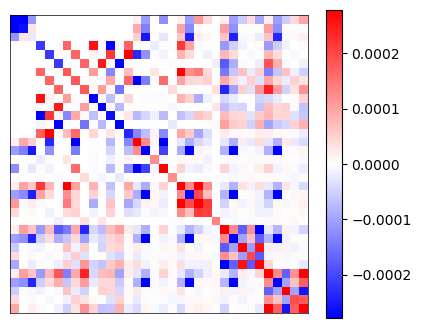

tensor(0.0003, dtype=torch.float64)

In [167]:
matshow(gt_outputs["hamiltonian"] - sccalculator.pred_ham)

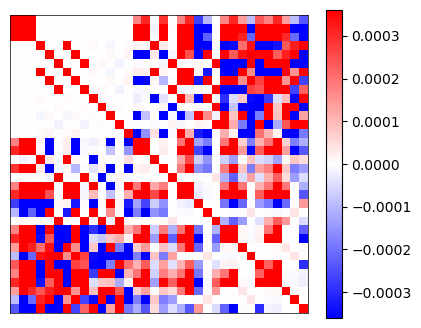

tensor(0.0004, dtype=torch.float64)

In [169]:
matshow(gt_outputs["hamiltonian"] - mf_hf.get_fock())

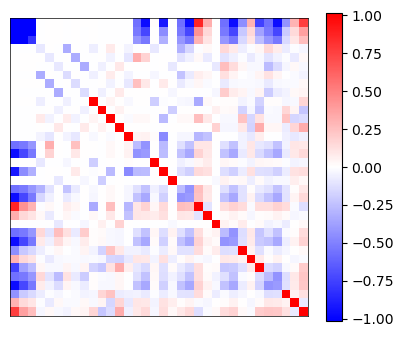

tensor(1.0163, dtype=torch.float64)

In [170]:
matshow(gt_outputs["hamiltonian"])

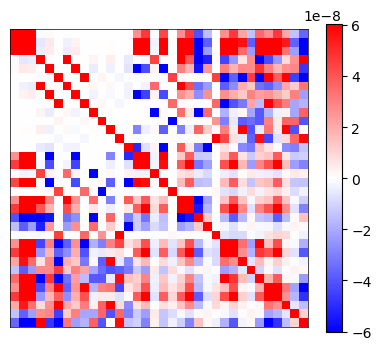

np.float64(6.027728733926097e-08)

In [173]:
matshow(mf_hf.get_fock() - gt_fock.get())